In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset_path = "C:/Users/hp/OneDrive/Desktop/efficientNet/dataset/images"

In [3]:
batch_size = 32
img_height = 128
img_width = 128

# Train + Validation
train_val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Test Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1210 files belonging to 7 classes.
Using 968 files for training.
Found 1210 files belonging to 7 classes.
Using 242 files for validation.


In [4]:
train_size = int(0.8 * len(train_val_dataset))

train_dataset = train_val_dataset.take(train_size)
val_dataset = train_val_dataset.skip(train_size)

In [5]:
class_names = train_val_dataset.class_names

print("Classes:", class_names)

print("Training batches:", len(train_dataset))
print("Validation batches:", len(val_dataset))
print("Testing batches:", len(test_dataset))

Classes: ['bags', 'outfit', 'pants', 'shirts', 'shoes', 'skirt', 'watches']
Training batches: 24
Validation batches: 7
Testing batches: 8


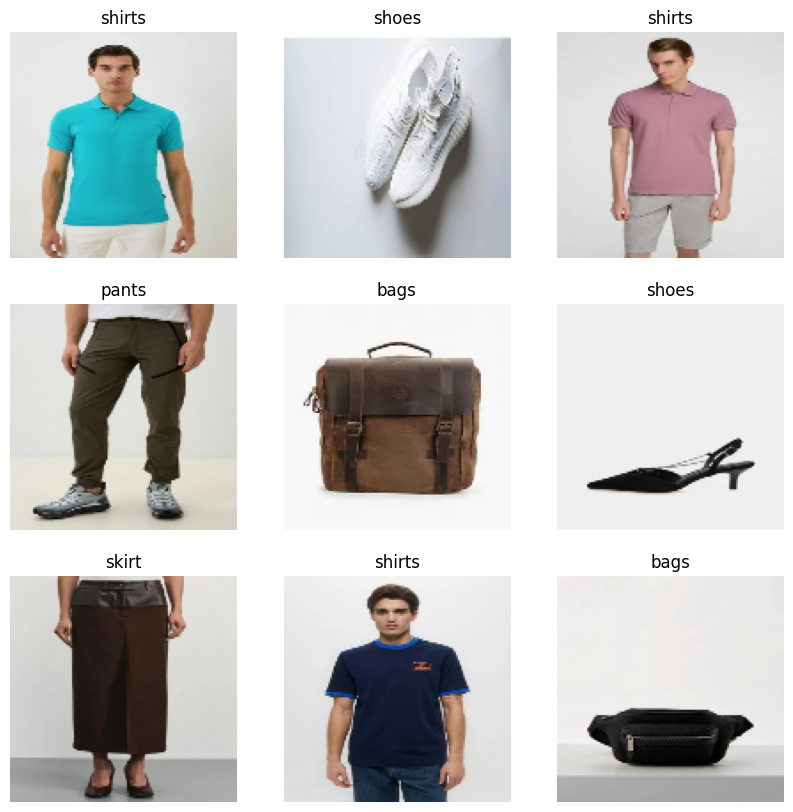

In [6]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [7]:
data_augmentation = keras.Sequential([
    
    layers.RandomFlip("horizontal"),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1)

])

In [8]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

    layers.RandomTranslation(0.1, 0.1)

])

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(7, activation='softmax')

])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 499ms/step - accuracy: 0.7539 - loss: 0.6551 - val_accuracy: 0.7900 - val_loss: 0.6032
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 559ms/step - accuracy: 0.7292 - loss: 0.6877 - val_accuracy: 0.8200 - val_loss: 0.5173
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.7513 - loss: 0.6604 - val_accuracy: 0.7950 - val_loss: 0.4732
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.7799 - loss: 0.6238 - val_accuracy: 0.8050 - val_loss: 0.4704
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step - accuracy: 0.7734 - loss: 0.6220 - val_accuracy: 0.8300 - val_loss: 0.4554
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 541ms/step - accuracy: 0.7734 - loss: 0.5901 - val_accuracy: 0.8500 - val_loss: 0.4499
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 522ms/step - accuracy: 0.7891 - loss: 0.5596 - val_accuracy: 0.8100 - val_loss: 0.4584
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 530ms/step - accuracy: 0.7682 - loss: 0.5957 - val_accu

In [15]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.7603 - loss: 0.7425
Test Accuracy: 0.7603305578231812


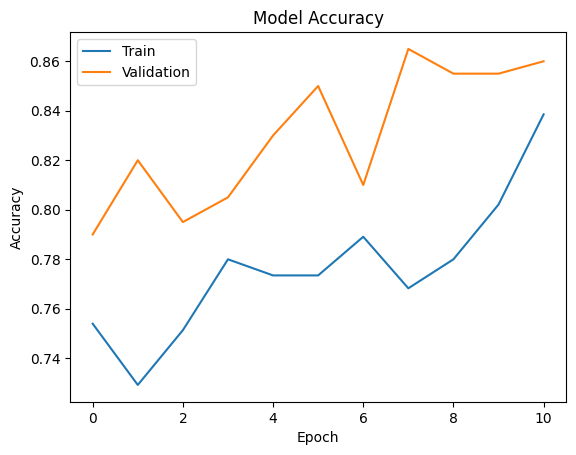

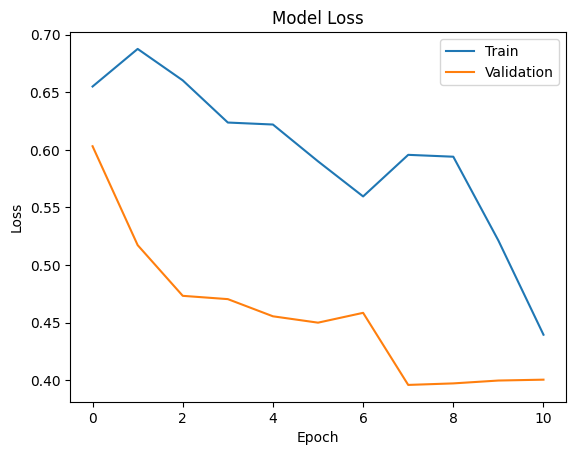

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

# saved model 


In [18]:
model.save("fashion_model.h5")

In [19]:
from tensorflow.keras.models import load_model

loaded_model = load_model("fashion_model.h5")

test_loss, test_accuracy = loaded_model.evaluate(test_dataset)

print("Loaded Model Accuracy:", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.7603 - loss: 0.7425
Loaded Model Accuracy: 0.7603305578231812
